This script provides some sampling for the experiments!


In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torch.optim import lr_scheduler
import numpy as np
import time
import matplotlib
from matplotlib import pyplot as pp
import scipy
from scipy.integrate import solve_ivp
import random
import functools
import pickle

In [2]:
"""
Mass-Spring-Damper (MSD)System \m * x'' + c * x' + k * x = u(t) + w(t)\n
For u(t) we consider different types of external forces: 

1) cos(wt), u(t) = A * cos(wt)
2) sin(wt), u(t) = A * sin(wt)
3) square(wt), u(t) = A * square(wt)
4) We want to implement a reference-tracking setup using a proportional controller:

u(t) = Kp*(r(t)-x(t)),  Kp > 0

w(t) is process noise (modelled or not modelled); let us assume it is icing
#To be discussed: [w(t) = c_ice * x'] Note = we are not currently doing this right now. 

Initial conditions: q(0) = 1, v(0) = 0
Sample for 60 second (1 minutes) with sampling rate of 1 or 10 Hz, --> [60, 600] timesteps (two sampling rates)


Sampling: 
Sampling/full-ground truth window: full window 600/600,  3/4 window (400/600) (300/600) small window (100/600)
Data sparcity: from 50 to 300 timesteps
Noise: Gaussian noise with 0.1 (we can vary later)
Context window length (how much data do I get) for a prediction horizon (how long in the future am I prediction): full window (300), long context window/short prediction window (250/50) medium context window/medium prediction window (150/150), small window (50/250)


"""


"\nMass-Spring-Damper (MSD)System \\m * x'' + c * x' + k * x = u(t) + w(t)\n\nFor u(t) we consider different types of external forces: \n\n1) cos(wt), u(t) = A * cos(wt)\n2) sin(wt), u(t) = A * sin(wt)\n3) square(wt), u(t) = A * square(wt)\n4) We want to implement a reference-tracking setup using a proportional controller:\n\nu(t) = Kp*(r(t)-x(t)),  Kp > 0\n\nw(t) is process noise (modelled or not modelled); let us assume it is icing\n#To be discussed: [w(t) = c_ice * x'] Note = we are not currently doing this right now. \n\nInitial conditions: q(0) = 1, v(0) = 0\nSample for 60 second (1 minutes) with sampling rate of 1 or 10 Hz, --> [60, 600] timesteps (two sampling rates)\n\n\nSampling: \nSampling/full-ground truth window: full window 600/600,  3/4 window (400/600) (300/600) small window (100/600)\nData sparcity: from 50 to 300 timesteps\nNoise: Gaussian noise with 0.1 (we can vary later)\nContext window length (how much data do I get) for a prediction horizon (how long in the future

In [3]:
#Sample ground truth data for different scenarios####
# 1. No external force
# 2. Different external forces; couldnt I put this as parameters? 


In [4]:
# ---------------------------
# Define ODE functions for non-harmonic massdamer systems with external forcing and disturbances term and potential reference tracking/simple P controller
# ---------------------------
def oscillator(t, y, m_true, c_true, k_true,u_t, w_t,Kp):
    '''This is the nonormalized oscillator ODE function with the forcing terms and disturbances'''
    x, v = y
    dxdt = v
    if Kp == None:
        u = u_t(t) if callable(u_t) else u_t
    else:
        u = u_t(t,x) if callable(u_t) else u_t
    w = w_t(t) if callable(w_t) else w_t
    dvdt = (-c_true*v - k_true*x)/m_true + (u + w)/m_true
    return [dxdt, dvdt]
# ---------------------------
# Define reference signal
# ---------------------------
def reference_signal(t):
    '''This is the reference signal r(t) for the reference tracking control'''
    r_t = np.zeros_like(t)
    r_t[(t < 20.0)] = 0.2
    r_t[(t > 20.0) & (t < 35.0)] = -0.2
    r_t[(t < 45.0) & (t >35.0)] = 0.2
    r_t[(t < 55.0) & (t >45.0)] = 0.4
    r_t[t >= 55.0] = 0.0
    return r_t
# ---------------------------
# Define the new forcing term
# ---------------------------

In [5]:
# ---------------------------
# sample ground truth and set parameters values for hormonic oscillator
# ---------------------------
# Physical parameters
# ---------------------------
m_true = 2 #mass in kg
c_true = 0.3 #damping coefficient in Ns/m
k_true = 0.2 #spring constant in N/m
Kp = 3.0 #proportional gain for reference tracking
Kp_array = [None,None,None,Kp]
# ---------------------------
#normalized parameters
# ---------------------------
delta_val = c_true/(2*m_true)
omega0_val = np.sqrt(k_true/m_true) #natural frequency
T_val = 1/omega0_val #characteristic time scale
# ---------------------------
# Forcing terms
# ---------------------------
u_1 = 0
u_2 = lambda t: np.sin(2 * np.pi * t)
u_3 = lambda t: scipy.signal.square(2 * np.pi * 0.5 * t)
u_4 = lambda t,x: Kp * (reference_signal(t) - x)  # assuming x(t)=0 for initial condition
u =[u_1,u_2,u_3,u_4]
u_legend = ['No external force', 'sinusoidal force', 'square wave force', 'reference tracking with P controller']
w_1 = 0
#w_2 = lambda t: 0.5 * np.random.normal(0, 1)

# ---------------------------
# boundary conditions
# ---------------------------
x0 = [1.0, 0.0]

# ---------------------------
# time span for simulation
# ---------------------------

t_span = (0, 60)                     # simulate from 0 to 60 seconds
t_eval = np.linspace(*t_span,600)  # time points for output is a 0.1 Hz sampling rate


# t_eval_col = np.linspace(*t_span, 30)  # reshape for compatibility with solve_ivp

# ---------------------------
# Ground truth data for inharmonic oscillator with different forcing terms  - no noise
# ---------------------------
sol_inharm = []
# for i in range(len(u)):
#     sol = solve_ivp(oscillator, t_span, x0, t_eval=t_eval,
#                     args=(m_true, c_true, k_true, u[i], w_1))
#     sol_inharm.append(sol)
for i in range(len(u)):
    sol = solve_ivp(oscillator, t_span, x0, t_eval=t_eval,
                    args=(m_true, c_true, k_true, u[i], w_1,Kp_array[i]))
    sol_inharm.append(sol)
print(f"Simulated the oscillator for {t_span} rate of 0.1 Hz. Created a list with for solutions of the different forcing terms; length of the list is {len(sol_inharm)} and we have {sol_inharm[0].t.shape} timepoints for each solution.\nAnd the shape of each solution is {sol_inharm[0].y.shape} with two states (position and velocity).")

# ---------------------------
# Create dictionary to hold different ground truth samples for each forcing term
# ---------------------------
data_groundtruth = {
        'ground_truth_params':
        {
                'x0': x0, # add the initial position/velocity vector
                't_span': t_span,
                't_eval': t_eval, # add the simulation time from 0 to 60
                'm_true': m_true, 
                'c_true': c_true,
                'k_true': k_true,
                'Kp_array': Kp_array,
                'delta_val': delta_val,
                'omega0_val':omega0_val,
                'T_val': T_val
         }
           # ---------------------------
}

for i in range (len(u)):
    data_groundtruth[f'model: {u_legend[i]}'] = {
        't': sol_inharm[i].t,
        'x': sol_inharm[i].y[0],
        'v': sol_inharm[i].y[1],
        }
print(f"Created a dictionary with the name \"data_groundtruth\" with the following keys {data_groundtruth.keys()}")






Simulated the oscillator for (0, 60) rate of 0.1 Hz. Created a list with for solutions of the different forcing terms; length of the list is 4 and we have (600,) timepoints for each solution.
And the shape of each solution is (2, 600) with two states (position and velocity).
Created a dictionary with the name "data_groundtruth" with the following keys dict_keys(['ground_truth_params', 'model: No external force', 'model: sinusoidal force', 'model: square wave force', 'model: reference tracking with P controller'])


<Figure size 1000x400 with 0 Axes>

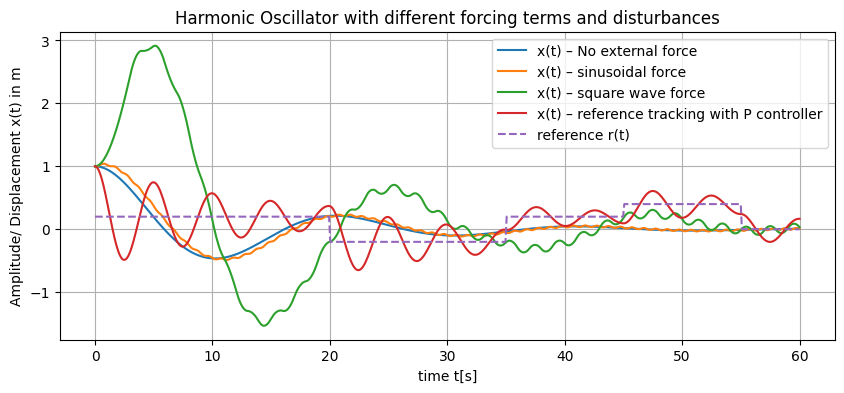

In [6]:
# ---------------------------
# plot ground truth solutions
# ---------------------------
pp.figure(figsize=(10,4))

#pp.scatter (t_eval_col, np.zeros_like(t_eval_col), s=5, lw=0, color="tab:green", label="collocation points", alpha=0.6)
# pp.plot(sol_harm.t, sol_harm.y[0],label="x(t) - harmonic")
pp.figure(figsize=(10,4))
for i in range(len(u)):
    pp.plot(sol_inharm[i].t, sol_inharm[i].y[0],label=f"x(t) – {u_legend[i]}")
pp.plot(sol_inharm[3].t, [reference_signal(t) for t in sol_inharm[3].t], '--', label='reference r(t)')
pp.xlabel("time t[s]")
pp.ylabel("Amplitude/ Displacement x(t) in m")
pp.title("Harmonic Oscillator with different forcing terms and disturbances")
pp.legend(); plt.grid(True)
pp.show()



Done. Created a dictionary with the name dict_keys(['No external force', 'sinusoidal force', 'square wave force', 'reference tracking with P controller']) with access to different models and sparcity levels.


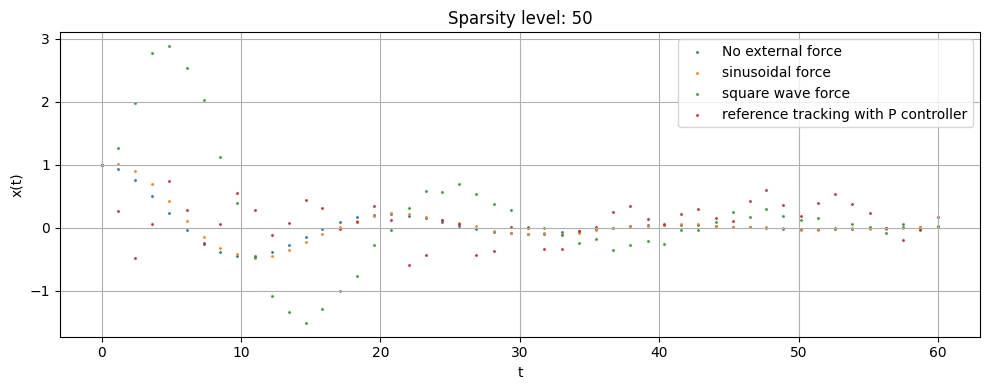

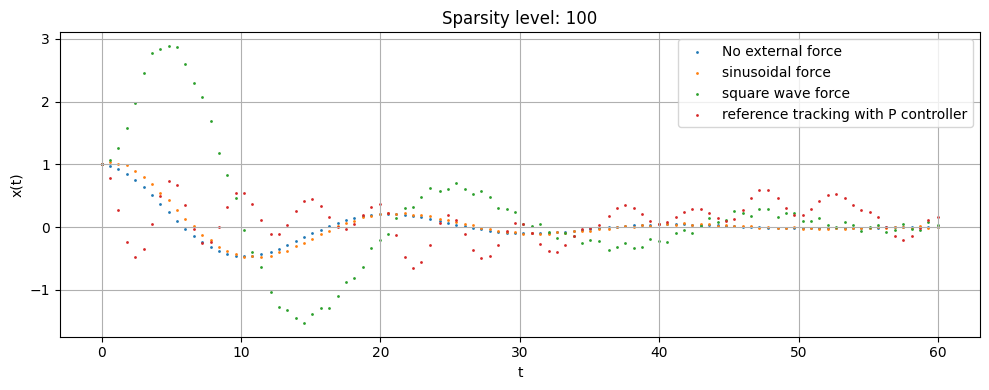

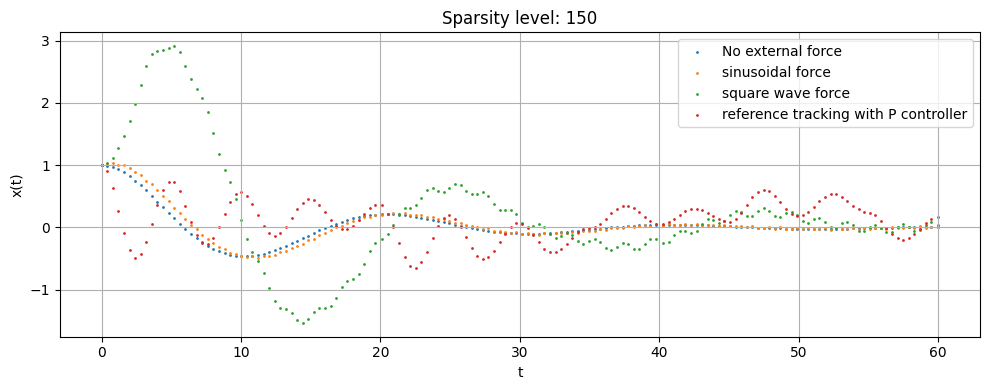

In [7]:
# ---------------------------
# Different sparcity levels with no noise and also evenly spaced samples
# ---------------------------

t_sparcity = [50,100,150] 
data_sampled = {}

for n in range(len(u)):
    model_name = u_legend[n]
    data_sampled[model_name] = {}
    #### Create different sparcity levels and turn into interger indices for indexing
    t_samples = [np.linspace(0, len(sol_inharm[n].t)-1, m).astype(int) for m in t_sparcity] # list of arrays with different sparcity levels
    #t_samples = [t_samples[m].astype(int) for m in range(len(t_samples))] # convert to integer indices for indexing
    for m_idx, m in enumerate(t_sparcity):
        sparcity_name = str(m)
        subsamples = t_samples[m_idx]  
        data_sampled[model_name][f'sparcity level {str(m)}'] = {
            't': sol_inharm[n].t[subsamples],
            'x': sol_inharm[n].y[0][subsamples],
            'v': sol_inharm[n].y[1][subsamples]} 
print(f"Done. Created a dictionary with the name {data_sampled.keys()} with access to different models and sparcity levels.")

# ---------------------------
# Plotting for the different sparcity levels -to check
# -
# go over the dictionary and plot the different sparcity levels for each forcing term
# ---------------------------
for s in t_sparcity:
    key = str(s)     # match dictionary keys
    pp.figure(figsize=(10,4))

    for model_name, sparsity_dict in data_sampled.items():
        data = sparsity_dict[f'sparcity level {key}']

        pp.scatter(
            data["t"],
            data["x"],
            label=model_name,
            s=4,
            lw=0
        )

    pp.title(f"Sparsity level: {s}")
    pp.xlabel("t")
    pp.ylabel("x(t)")
    pp.legend()
    pp.grid(True)
    pp.tight_layout()
    pp.show()

Done. Created a dictionary with the name dict_keys(['No external force', 'sinusoidal force', 'square wave force', 'reference tracking with P controller']) with access to different models and sparcity levels but randomily distributed.


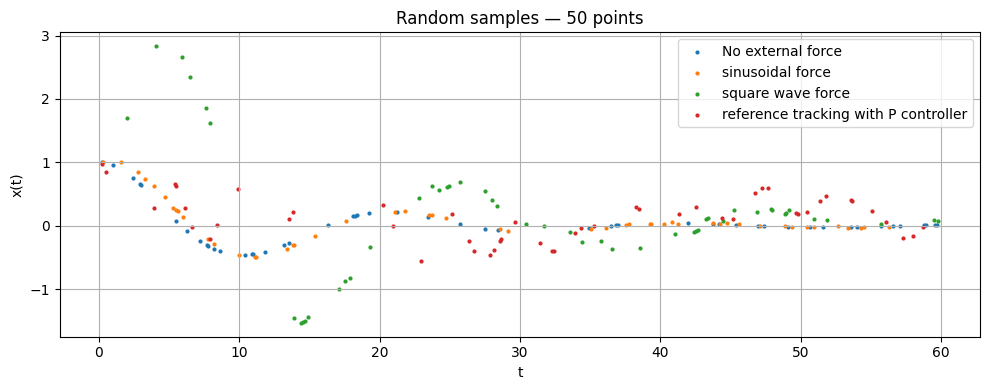

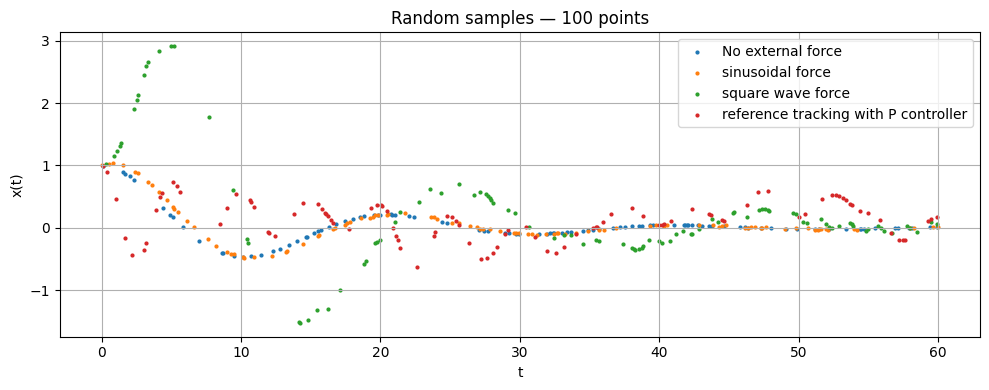

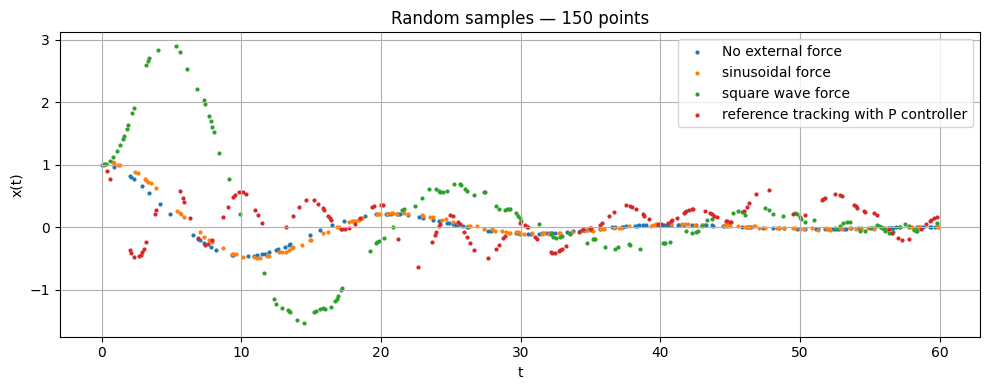

In [8]:
# ---------------------------
# Sparsity levels with random samples
# ---------------------------
t_sparsity = [50, 100, 150]  # number of random samples per plot
np.random.seed(42)  # reproducible random samples

# ---------------------------
# Build dictionary with random samples
# ---------------------------
data_sampled_random = {}

for n in range(len(u)):
    model_name = u_legend[n]
    data_sampled_random[model_name] = {}

    t_full = sol_inharm[n].t
    x_full = sol_inharm[n].y[0]
    v_full = sol_inharm[n].y[1]

    for m in t_sparsity:
        sparsity_name = str(m)

        # Draw m random unique indices
        indices = np.random.choice(len(t_full), size=m, replace=False)
        indices = np.sort(indices)  # optional, for plotting in time order

        data_sampled_random[model_name][sparsity_name] = {
            "t": t_full[indices],
            "x": x_full[indices],
            "v": v_full[indices]
        }
print(f"Done. Created a dictionary with the name {data_sampled_random.keys()} with access to different models and sparcity levels but randomily distributed.")
# ---------------------------
# Plotting random samples
# ---------------------------
for s in t_sparsity:
    key = str(s)
    pp.figure(figsize=(10,4))

    for model_name, sparsity_dict in data_sampled_random.items():
        data = sparsity_dict[key]

        pp.scatter(
            data["t"],
            data["x"],
            label=model_name,
            s=4
        )

    pp.title(f"Random samples — {s} points")
    pp.xlabel("t")
    pp.ylabel("x(t)")
    pp.legend()
    pp.grid(True)
    pp.tight_layout()
    pp.show()

The keys for the dictionary for the model "reference tracking with P controller" are "dict_keys(['sparcity level 50', 'sparcity level 100', 'sparcity level 150'])"
Done. Created a dictionary with the name dict_keys(['No external force', 'sinusoidal force', 'square wave force', 'reference tracking with P controller']) with access to different models and sparcity levels.


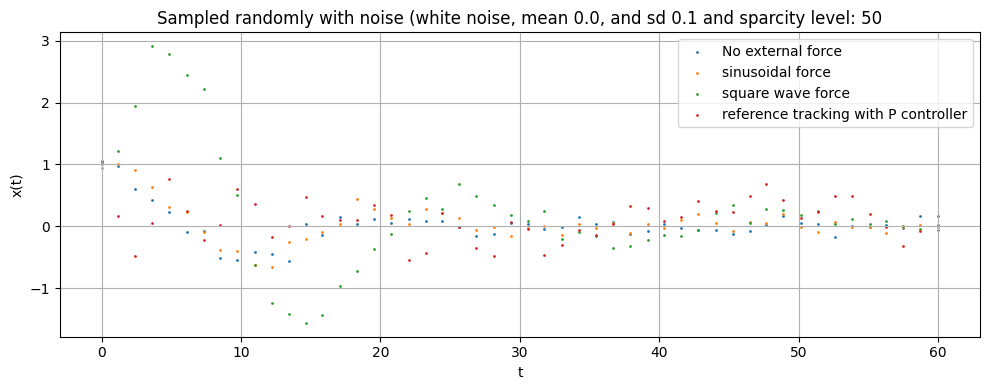

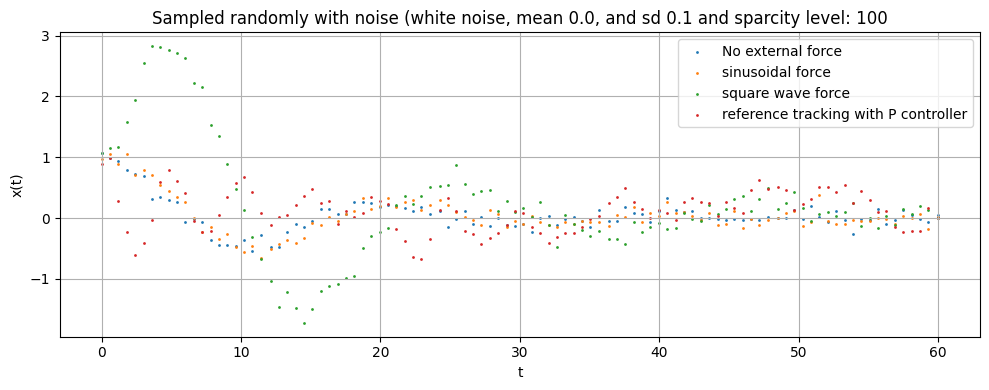

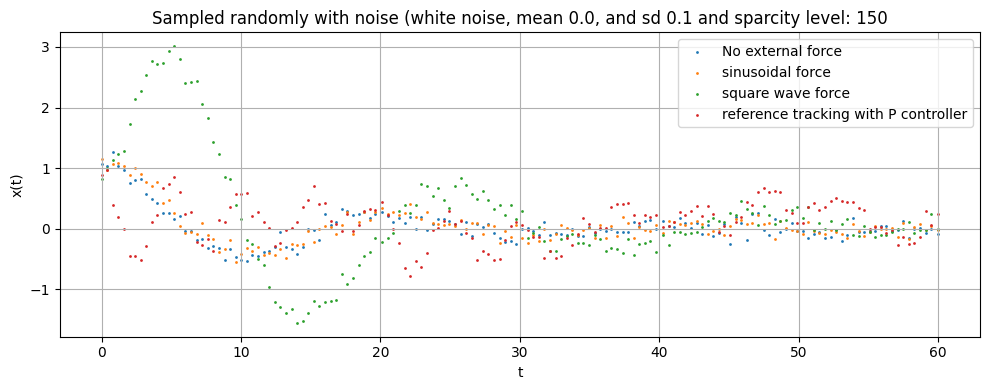

In [9]:
# ---------------------------
# Adding noise to the sample data with different sparcity levels
# ---------------------------
data_sampled_random_with_noise = {}
sd = 0.1
mean = 0.0

for n in range(len(u)):
    model_name = u_legend[n]
    data_sampled_random_with_noise[model_name] = {}
    for i, m in enumerate(t_sparcity):
        x_noise = data_sampled[model_name][f'sparcity level {str(m)}']['x'] + np.random.normal(mean, sd, size=data_sampled[model_name][f'sparcity level {str(m)}']['x'].shape)
        v_noise = data_sampled[model_name][f'sparcity level {str(m)}']['x'] + np.random.normal(mean, sd, size=data_sampled[model_name][f'sparcity level {str(m)}']['v'].shape)
        data_sampled_random_with_noise[model_name][f'sparcity level {str(m)}'] = {
            't': data_sampled[model_name][f'sparcity level {str(m)}']['t'],
            'x': x_noise,
            'v': v_noise} 
print(f"The keys for the dictionary for the model \"{model_name}\" are \"{data_sampled[model_name].keys()}\"")
print(f"Done. Created a dictionary with the name {data_sampled.keys()} with access to different models and sparcity levels.")

# ---------------------------
# Plotting for the different sparcity levels -to check
# -
# go over the dictionary and plot the different sparcity levels for each forcing term
# ---------------------------
for s in t_sparcity:
    key = str(s)     # match dictionary keys
    pp.figure(figsize=(10,4))

    for model_name, sparsity_dict in data_sampled_random_with_noise.items():
        data = sparsity_dict[f'sparcity level {key}']

        pp.scatter(
            data["t"],
            data["x"],
            label=model_name,
            s=4,
            lw=0
        )

    pp.title(f"Sampled randomly with noise (white noise, mean {mean}, and sd {sd} and sparcity level: {s}")
    pp.xlabel("t")
    pp.ylabel("x(t)")
    pp.legend()
    pp.grid(True)
    pp.tight_layout()
    pp.show()

In [10]:
# ---------------------------
# Sampling collocation points
# ---------------------------
N_colloc = [50,100,150]
t_colloc = [np.sort(np.random.uniform(0, t_span[1],n)) for n in N_colloc]

data_colloc = {}
data_colloc = {
    f"Collocation points {n}": np.linspace(0, t_span[1], n)
    for n in N_colloc
}  
print(f"Created a dictionary with the name {data_colloc.keys()} with access to different collocation points for different numbers of collocation points.")


Created a dictionary with the name dict_keys(['Collocation points 50', 'Collocation points 100', 'Collocation points 150']) with access to different collocation points for different numbers of collocation points.


In [11]:
print("This script created the following dictionaries to hold data samples:\n- data_groundtruth: holds the full ground truth solutions for different forcing terms.\n- data_sampled: holds evenly spaced samples at different sparcity levels for each forcing term.\n- data_sampled_random: holds randomly sampled points at different sparcity levels for each forcing term.\n- data_sampled_random_with_noise: holds randomly sampled points with added Gaussian noise at different sparcity levels for each forcing term.\n- data_colloc: holds collocation points for different specified numbers of points.")

This script created the following dictionaries to hold data samples:
- data_groundtruth: holds the full ground truth solutions for different forcing terms.
- data_sampled: holds evenly spaced samples at different sparcity levels for each forcing term.
- data_sampled_random: holds randomly sampled points at different sparcity levels for each forcing term.
- data_sampled_random_with_noise: holds randomly sampled points with added Gaussian noise at different sparcity levels for each forcing term.
- data_colloc: holds collocation points for different specified numbers of points.


In [12]:
# ---------------------------
# Store the data so that they can be loaded by another script
# ---------------------------

with open('massdamper_data.pkl', 'wb') as f:
    pickle.dump({
        'data_groundtruth': data_groundtruth,
        'data_sampled': data_sampled,
        'data_sampled_random': data_sampled_random,
        'data_sampled_random_with_noise': data_sampled_random_with_noise,
        'data_colloc': data_colloc
    }, f)

In [13]:
# ---------------------------
# load the data alter (to check)
# ---------------------------
with open('massdamper_data.pkl', 'rb') as f:
    data = pickle.load(f)

data_groundtruth_loaded = data['data_groundtruth']
data_sampled_loaded = data['data_sampled']
data_sampled_random_loaded = data['data_sampled_random']
data_sampled_random_with_noise_loaded = data['data_sampled_random_with_noise']
data_colloc_loaded = data['data_colloc']

print(data_groundtruth_loaded.keys())
print("Data loaded successfully from 'massdamper_data.pkl'.")

dict_keys(['ground_truth_params', 'model: No external force', 'model: sinusoidal force', 'model: square wave force', 'model: reference tracking with P controller'])
Data loaded successfully from 'massdamper_data.pkl'.
